# Lab 4

The glasses detector dataset contains synthetic images of faces with various types of glasses (regular, sunglasses, no glasses, etc.).
We will solve a binary classification problem: whether a face has glasses or not.<br>
Dataset link: https://www.kaggle.com/datasets/mantasu/glasses-detector  

### Install and import nessesary packages

In [ ]:
%pip list

Package                                  Version
---------------------------------------- -------------------
absl-py                                  1.4.0
accelerate                               1.13.0
access                                   1.1.10.post3
affine                                   2.4.0
aiofiles                                 24.1.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.5
aiosignal                                1.4.0
aiosqlite                                0.22.1
alabaster                                1.0.0
albucore                                 0.0.24
albumentations                           2.0.8
ale-py                                   0.11.2
alembic                                  1.18.4
altair                                   5.5.0
annotated-doc                            0.0.4
annotated-types                          0.7.0
antlr4-python3-runtime                   4.9.3
anyio                         

In [ ]:
%%capture
!pip install torch torchvision kaggle matplotlib pillow scikit-learn kagglehub

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from PIL import Image

### Download dataset

In [ ]:
import kagglehub
import shutil
import os

# скачивание
path = kagglehub.dataset_download("mantasu/glasses-detector")
print("Downloaded to:", path)

# куда копируем
target_path = "/content/sample_data/glasses-detector"

if os.path.exists(target_path):
    shutil.rmtree(target_path)

# копирование
shutil.copytree(path, target_path)

print("Dataset copied to:", target_path)

100%|██████████| 2.23G/2.23G [00:54<00:00, 43.8MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/mantasu/glasses-detector/versions/7
Dataset copied to: /content/sample_data/glasses-detector


In [ ]:
# Let's declare global variables
DATA_DIR = '/content/sample_data/glasses-detector/classification/anyglasses/glasses-detection'  # path to dataset
BATCH_SIZE = 32 # a fixed amount of data processed by a machine learning model in one iteration
EPOCHS = 35  # one full cycle of model training, in which it runs the entire training dataset through itself once
LR = 1e-3 # learning rate
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(10)

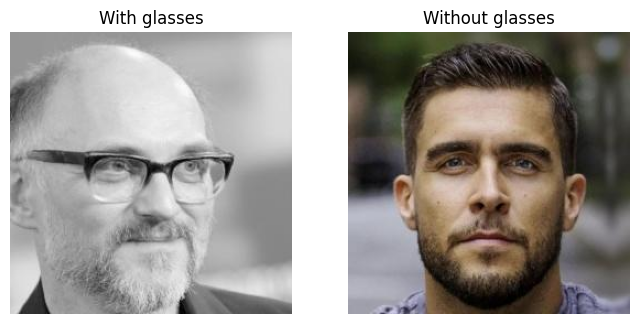

In [ ]:
img1 = Image.open("/content/sample_data/glasses-detector/classification/anyglasses/glasses-detection/train/anyglasses/-c3-96sterreichischer_filmpreis_2019_foto_call_markus_schleinzer_1_jpg.rf.aefdf0cb7391802eac85002d0ed648cc.jpg")
img2 = Image.open("/content/sample_data/glasses-detector/classification/anyglasses/glasses-detection/train/no_anyglasses/-d0-94-d0-b6-d0-be-d1-88_-d0-a1-d0-b5-d0-b3-d0-b0-d1-80-d1-80-d0-b0_jpg.rf.49974ed010d32b34cab913510a746812.jpg")

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img1)
plt.title("With glasses")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img2)
plt.title("Without glasses")
plt.axis("off")

plt.show()

### Prepare dataset

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

In [ ]:
train_dataset = datasets.ImageFolder(f"{DATA_DIR}/train", transform=transform)
val_dataset = datasets.ImageFolder(f"{DATA_DIR}/val", transform=transform)
test_dataset = datasets.ImageFolder(f"{DATA_DIR}/test", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

class_names = train_dataset.classes
print("Classes:", class_names)

Classes: ['anyglasses', 'no_anyglasses']


In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

model = SimpleCNN(num_classes=len(class_names)).to(DEVICE)

In [ ]:
# hyperparams
criterion = nn.CrossEntropyLoss() # loss function
optimizer = optim.Adam(model.parameters(), lr=LR) # optimizer and learning rate

In [ ]:
# Train model
def train():
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

train()
torch.save(model.state_dict(), "cnn_glasses.pth")


Epoch 1, Loss: 1.0453
Epoch 2, Loss: 0.6163
Epoch 3, Loss: 0.5549
Epoch 4, Loss: 0.5776
Epoch 5, Loss: 0.5280
Epoch 6, Loss: 0.3893
Epoch 7, Loss: 0.4172
Epoch 8, Loss: 0.8760
Epoch 9, Loss: 0.7761
Epoch 10, Loss: 0.6375
Epoch 11, Loss: 0.5353
Epoch 12, Loss: 0.9058
Epoch 13, Loss: 0.5086
Epoch 14, Loss: 0.5162
Epoch 15, Loss: 0.4788
Epoch 16, Loss: 0.6311
Epoch 17, Loss: 0.4798
Epoch 18, Loss: 0.4578
Epoch 19, Loss: 0.4138
Epoch 20, Loss: 0.3462
Epoch 21, Loss: 0.3024
Epoch 22, Loss: 0.4584
Epoch 23, Loss: 0.5289
Epoch 24, Loss: 0.4788
Epoch 25, Loss: 0.2958
Epoch 26, Loss: 0.5056
Epoch 27, Loss: 0.4815
Epoch 28, Loss: 0.4883
Epoch 29, Loss: 0.3464
Epoch 30, Loss: 0.4309
Epoch 31, Loss: 0.5279
Epoch 32, Loss: 0.4856
Epoch 33, Loss: 0.2892
Epoch 34, Loss: 0.4545
Epoch 35, Loss: 0.5410


In [ ]:
def validate():
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    print(f"Validation accuracy: {correct/total:.4f}")

validate()

Validation accuracy: 0.9154


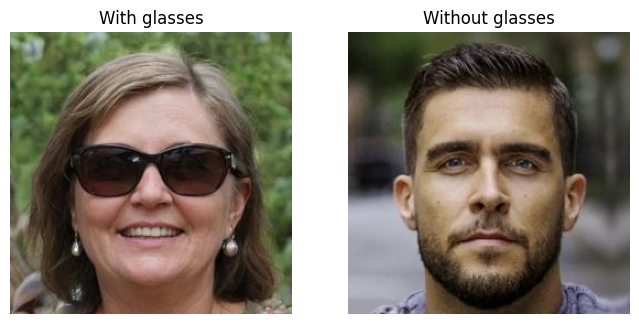

anyglasses
no_anyglasses


In [ ]:
# inference example
def predict(image_path):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        outputs = model(image)
        _, pred = torch.max(outputs, 1)

    return class_names[pred.item()]


img1 = Image.open("/content/sample_data/glasses-detector/classification/sunglasses/glasses-image-dataset/test/sunglasses/face-203_jpg.rf.7b609506d867a2e37467b82cdf24f921.jpg")
img2 = Image.open("/content/sample_data/glasses-detector/classification/anyglasses/glasses-detection/train/no_anyglasses/-d0-94-d0-b6-d0-be-d1-88_-d0-a1-d0-b5-d0-b3-d0-b0-d1-80-d1-80-d0-b0_jpg.rf.49974ed010d32b34cab913510a746812.jpg")

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img1)
plt.title("With glasses")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img2)
plt.title("Without glasses")
plt.axis("off")

plt.show()
print(predict("/content/sample_data/glasses-detector/classification/sunglasses/glasses-image-dataset/test/sunglasses/face-203_jpg.rf.7b609506d867a2e37467b82cdf24f921.jpg"))
print(predict("/content/sample_data/glasses-detector/classification/anyglasses/glasses-detection/train/no_anyglasses/-d0-94-d0-b6-d0-be-d1-88_-d0-a1-d0-b5-d0-b3-d0-b0-d1-80-d1-80-d0-b0_jpg.rf.49974ed010d32b34cab913510a746812.jpg"))


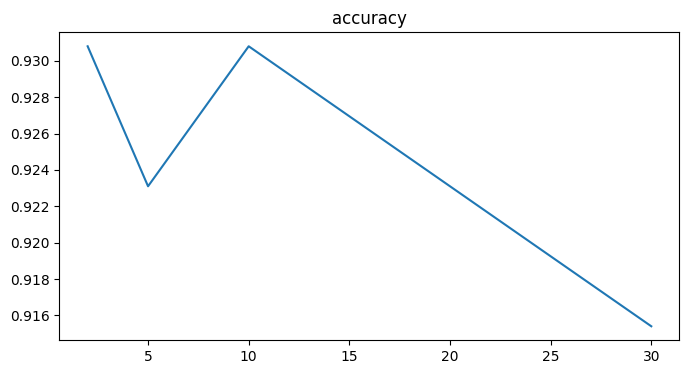

In [ ]:
plt.figure(figsize=(8,4))

plt.plot([2,5,10,20,30], [0.9308,0.9231,0.9308,0.9231,0.9154])
plt.title("accuracy")

plt.show()